In [39]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import argparse
from pathlib import Path
import csv

In [40]:
image_path = Path('.').parent / '../maps/cdc_2024/cdc_2024_edited_with_line.pgm'
output_path = Path('.').parent / '../output'  
output_path.mkdir(exist_ok=True)

print(f"Processing {image_path}...")


Processing ../maps/cdc_2024/cdc_2024_edited_with_line.pgm...


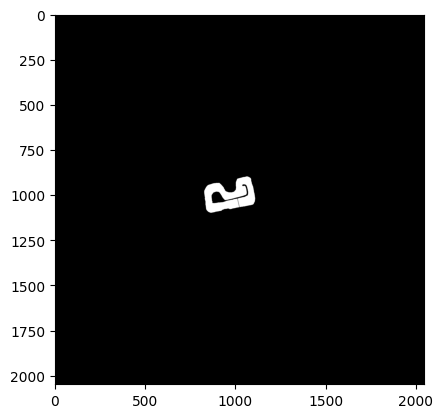

In [41]:
# Load the image
img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if img is None:
    raise ValueError(f"Could not load image from {image_path}")
plt.imshow(img, cmap='gray')

In [42]:
print(f"Loaded image with shape: {img.shape}")

# Threshold the image to create a binary image
_, binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

# Invert if the track is white (assuming track is darker than background)
if np.mean(binary) > 127: # type: ignore
    binary = 255 - binary

Loaded image with shape: (2048, 2048)


In [43]:
# Find contours - for boundary extraction
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
len(contours)

1

In [44]:
contours

(array([[[1058,  899]],
 
        [[1057,  900]],
 
        [[1055,  900]],
 
        [[1054,  901]],
 
        [[1051,  901]],
 
        [[1050,  902]],
 
        [[1043,  902]],
 
        [[1042,  903]],
 
        [[1038,  903]],
 
        [[1037,  904]],
 
        [[1036,  904]],
 
        [[1035,  905]],
 
        [[1032,  905]],
 
        [[1031,  906]],
 
        [[1028,  906]],
 
        [[1027,  907]],
 
        [[1024,  907]],
 
        [[1023,  908]],
 
        [[1020,  908]],
 
        [[1019,  909]],
 
        [[1017,  909]],
 
        [[1016,  910]],
 
        [[1012,  910]],
 
        [[1011,  911]],
 
        [[1010,  911]],
 
        [[1007,  914]],
 
        [[1007,  916]],
 
        [[1006,  917]],
 
        [[1006,  919]],
 
        [[1005,  920]],
 
        [[1005,  921]],
 
        [[1004,  922]],
 
        [[1004,  924]],
 
        [[1003,  925]],
 
        [[1003,  926]],
 
        [[1002,  927]],
 
        [[1002,  930]],
 
        [[1001,  931]],
 
        [[10

In [45]:

# Find the largest contour (assuming it's the track)
largest_contour = max(contours, key=cv2.contourArea)
print("Largest contour has shape:", largest_contour.shape)

Largest contour has shape: (355, 1, 2)


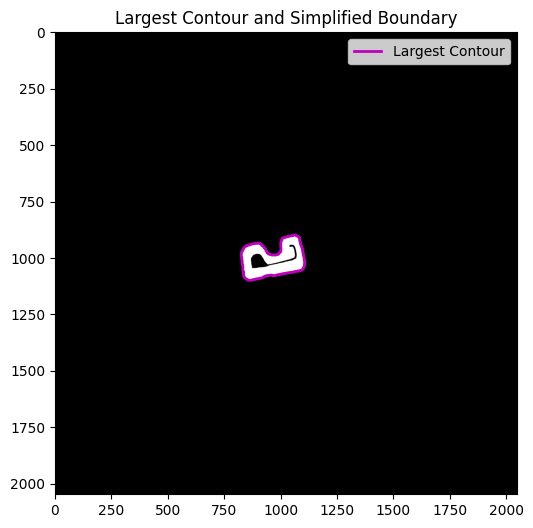

In [46]:
boundary_points = largest_contour

# Extract coordinates for plotting
largest_contour_coords =    [(point[0][0], point[0][1]) for point in largest_contour] # type: ignore
boundary_coords =           [(point[0][0], point[0][1]) for point in boundary_points] # type: ignore

# Plot immediately
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')  # Show the binary image as background
# Plot raw largest contour
largest_x = [p[0] for p in largest_contour_coords]
largest_y = [p[1] for p in largest_contour_coords]
plt.plot(largest_x, largest_y, 'm-', linewidth=2, label='Largest Contour')

plt.title('Largest Contour and Simplified Boundary')
plt.legend()
plt.show()


In [47]:

# Erode to create an artificial inner boundary
kernel = np.ones((3, 3), np.uint8)
eroded = cv2.erode(binary, kernel, iterations=3)  # Adjust iterations as needed

# Extract all contours with hierarchy using RETR_CCOMP
contours, hierarchy = cv2.findContours(eroded, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

# Find the contour with the smallest area
inner_contour = None
if contours:
    inner_contour = min(contours, key=cv2.contourArea)
    # Optionally filter out tiny noise contours
    if cv2.contourArea(inner_contour) < 50:  # Adjust threshold as needed
        print("Smallest contour too small, might be noise.")
        inner_contour = None


In [48]:
inner_contour  = inner_contour.reshape(-1, 2) 
inner_contour_coords = inner_contour

In [49]:

# Simplify and get coordinates
# if inner_contour is not None:
#     print("Smallest contour shape before:", inner_contour.shape)
#     epsilon = 0.005 * cv2.arcLength(inner_contour, True)
#     inner_boundary = cv2.approxPolyDP(inner_contour, epsilon, True)
#     inner_coords = [(point[0][0], point[0][1]) for point in inner_boundary] # type: ignore
#     print("Smallest contour coods after:", inner_coords)
#     print(f"Smallest contour points: {len(inner_coords)}")
#     print(f"First few points: {inner_coords[:5]}")
# else:
#     inner_coords = []
#     print("No contours detected after erosion.")

# # Plot the smallest contour
# plt.figure(figsize=(8, 6))
# plt.imshow(binary, cmap='gray')
# if inner_coords:
#     inner_x = [p[0] for p in inner_coords]
#     inner_y = [p[1] for p in inner_coords]
#     plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')
#     plt.legend()
# else:
#     plt.title('No Inner Contour Found')
# plt.title('Smallest Inner Contour on Original Binary')
# plt.show()


In [50]:
## Get the length of each

len(largest_contour_coords), len(inner_contour_coords)

(355, 271)

In [51]:
## Get outside point to inside point ratio
ratio  = len(largest_contour_coords) / len(inner_contour_coords)
ratio

1.3099630996309963

In [52]:
import numpy as np
import cv2

midpoints = []

# Convert contours to NumPy arrays
inner_array = np.array(inner_contour_coords)
outer_array = np.array(largest_contour_coords)

def does_line_cross_contour(p1, p2, contour):
    """
    Check if the line segment (p1 -> p2) intersects the given contour.
    """
    for i in range(len(contour)):
        q1 = contour[i]
        q2 = contour[(i + 1) % len(contour)]  # Wrap around
        if cv2.clipLine((q1[0], q1[1], q2[0], q2[1]), p1, p2):
            return True  # Line crosses the contour
    return False

for inner_point in inner_contour_coords:
    # Compute distances
    distances = np.linalg.norm(outer_array - np.array(inner_point), axis=1)

    # Sort indices by distance
    sorted_indices = np.argsort(distances)

    # Find the closest valid outer point (not crossing the track)
    for closest_index in sorted_indices:
        outer_point = largest_contour_coords[closest_index]
        
        # Check if the midpoint crosses the inner contour (i.e., the "wall")
        if not does_line_cross_contour(inner_point, outer_point, inner_array):
            # Compute midpoint
            midpoint_x = (inner_point[0] + outer_point[0]) / 2
            midpoint_y = (inner_point[1] + outer_point[1]) / 2
            midpoint = (midpoint_x, midpoint_y)

            midpoints.append(midpoint)
            print(f"Midpoint between {inner_point} and {outer_point} is {midpoint}")
            break  # Found a valid point, move to the next inner point


In [53]:
# Skeletonize to get centerline
# Distance transform + adaptive thresholding
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)

# Normalize for visualization
dist_norm = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX)

# Improve skeleton by using an adaptive threshold based on max distance
max_dist = np.max(dist_transform[binary > 0])  # Max distance within track
factor = 0.5 ## Factor
thresh_value = max_dist * factor  # Threshold at half the max distance (adjustable)
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton = skeleton.astype(np.uint8)

# Optional: Thin the skeleton with a single erosion step to refine it
kernel = np.ones((3, 3), np.uint8)
skeleton = cv2.erode(skeleton, kernel, iterations=1)

In [54]:
# # Find centerline points
# centerline_points = np.where(skeleton > 0)
# centerline_coords = [(x, y) for y, x in zip(centerline_points[0], centerline_points[1])]

# # Sort centerline points to follow the track
# if len(centerline_coords) > 1:
#     sorted_centerline = [centerline_coords[0]]
#     remaining = centerline_coords[1:]
    
#     while remaining:
#         print("Remaining points:", len(remaining))
#         last_point = sorted_centerline[-1]
#         distances = [np.sqrt((p[0] - last_point[0])**2 + (p[1] - last_point[1])**2) for p in remaining]
#         closest_idx = np.argmin(distances)
#         sorted_centerline.append(remaining[closest_idx])
#         remaining.pop(closest_idx)
        
#         # Break if remaining points are too far (gaps in track)
#         if distances[closest_idx] > 20 and len(sorted_centerline) > len(centerline_coords) // 2:
#             break
            
#     centerline_coords = sorted_centerline

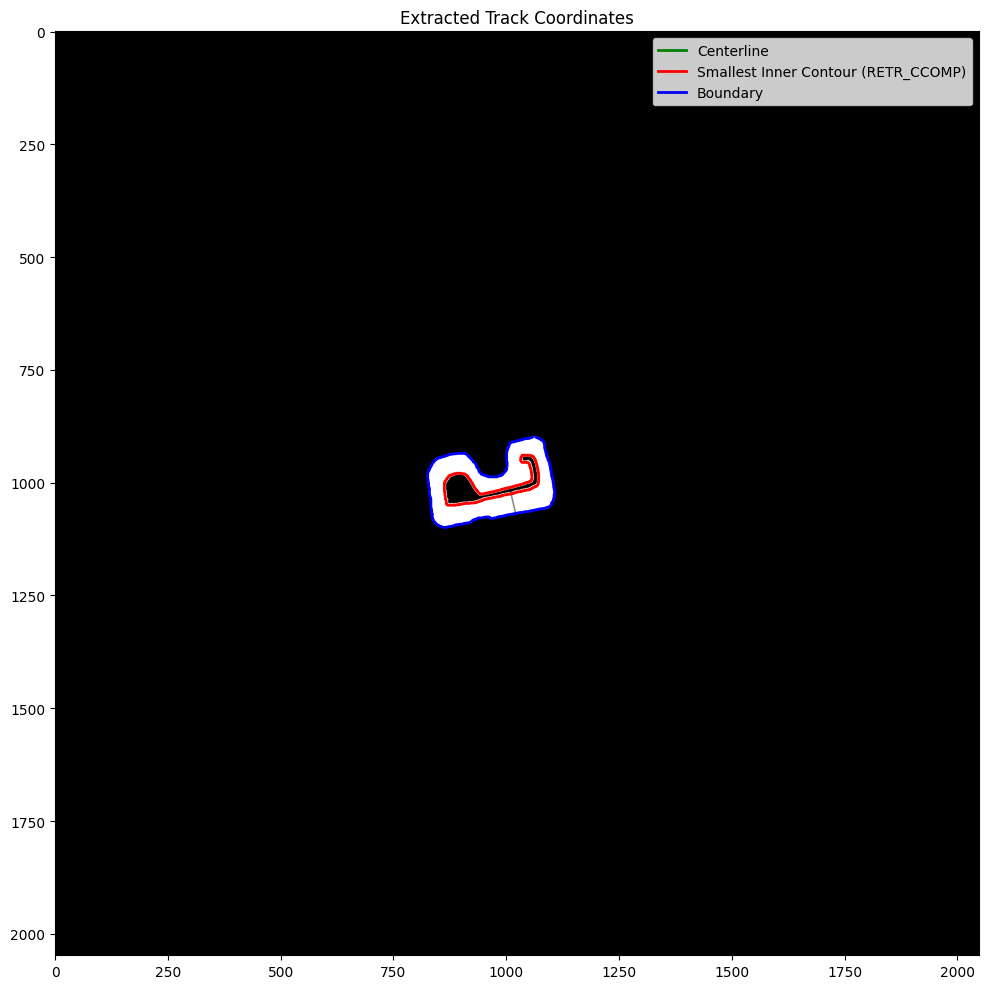

<Figure size 640x480 with 0 Axes>

In [55]:
# Save to CSV if output path is provided
if output_path:
    with open(output_path / 'centerline.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(midpoints)
        
    with open(output_path / 'boundary.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(boundary_coords)

    plt.imsave(output_path / 'distance_transform.png', dist_norm, cmap='hot')
    plt.imsave(output_path / 'centerline.png', cv2.cvtColor(skeleton, cv2.COLOR_GRAY2RGB))
    plt.imsave(output_path / 'binary.png', binary, cmap='gray')
    plt.imsave(output_path / 'track.png', cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))
    plt.imsave(output_path / 'track_with_coords.png', cv2.cvtColor(img, cv2.COLOR_GRAY2RGB))    

# Visualize results

plt.figure(figsize=(12, 10))

# # Original image
# plt.subplot(2, 2, 1)
# plt.imshow(img, cmap='gray')
# plt.title('Original Track Image')

# # Binary image
# plt.subplot(2, 2, 2)
# plt.imshow(binary, cmap='gray')
# plt.title('Binary Track Image')

# # Distance transform
# plt.subplot(2, 2, 3)
# plt.imshow(dist_norm, cmap='hot')
# plt.title('Distance Transform')

# Result with coordinates
# plt.subplot(2, 2, 4)
plt.imshow(img, cmap='gray')
centerline_x = [p[0] for p in midpoints]
centerline_y = [p[1] for p in midpoints]
plt.plot(centerline_x, centerline_y, 'g-', linewidth=2, label='Centerline')
boundary_x = [p[0] for p in boundary_coords]
boundary_y = [p[1] for p in boundary_coords]

# if inner_contour_coords:
inner_x = [p[0] for p in inner_contour_coords]
inner_y = [p[1] for p in inner_contour_coords]
plt.plot(inner_x, inner_y, 'r-', linewidth=2, label='Smallest Inner Contour (RETR_CCOMP)')

plt.plot(boundary_x, boundary_y, 'b-', linewidth=2, label='Boundary')
plt.title('Extracted Track Coordinates')
plt.legend()

plt.tight_layout()
plt.show()
if output_path:
    plt.savefig(output_path / 'track_with_coords.png')

## Try to get skeleton for centerline

In [56]:
# Normalize for visualization (optional)
dist_norm = cv2.normalize(dist_transform, None, 0, 255, cv2.NORM_MINMAX) # type: ignore
dist_norm

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2048, 2048), dtype=float32)

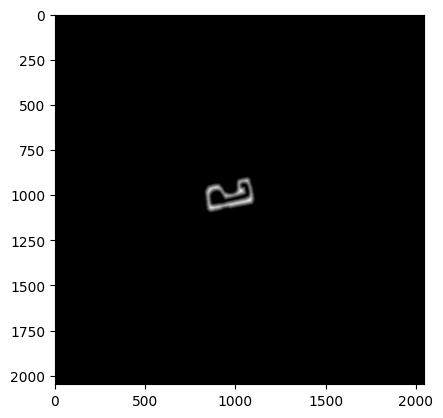

In [57]:
# Display the binary image as the background
plt.imshow(dist_norm, cmap='gray')

In [58]:
np.max(dist_norm)

np.float32(255.0)

In [59]:
# Threshold at a fraction of max distance
max_dist = np.max(dist_transform[binary > 0])
thresh_value = max_dist * 0.5  # Adjustable factor (0.5 works well for many cases)
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(2048, 2048), dtype=float32)

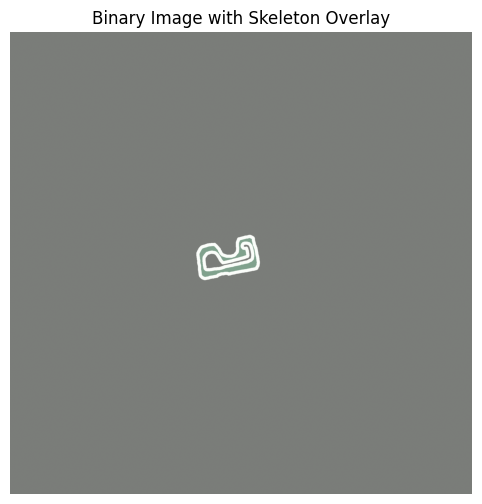

In [60]:
# Create a figure
plt.figure(figsize=(8, 6))

# Display the binary image as the background
plt.imshow(binary, cmap='gray')

# Overlay the skeleton in a distinct color (e.g., green)
plt.imshow(skeleton, cmap='Greens', alpha=0.5)  # alpha controls transparency

# Add titles and show the plot
plt.title('Binary Image with Skeleton Overlay')
plt.axis('off')  # Optional: hide axes
plt.show()

## Example
Suppose your binary image has a 5-pixel-wide horizontal track:

0 0 0 0 0 0 0
0 255 255 255 255 0 0
0 0 0 0 0 0 0

dist_transform might look like:

0 0 0 0 0 0 0
0 1 2 2.24 1 0 0
0 0 0 0 0 0 0

In [61]:

# Skeletonize to get centerline
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
dist_transform.shape

(2048, 2048)

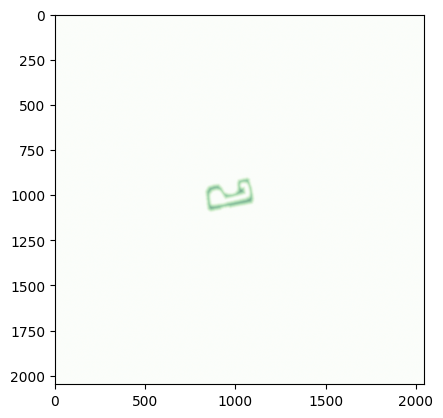

In [62]:

# Overlay the skeleton in a distinct color (e.g., green)
plt.imshow(dist_transform, cmap='Greens', alpha=0.5)  # alpha controls transparency

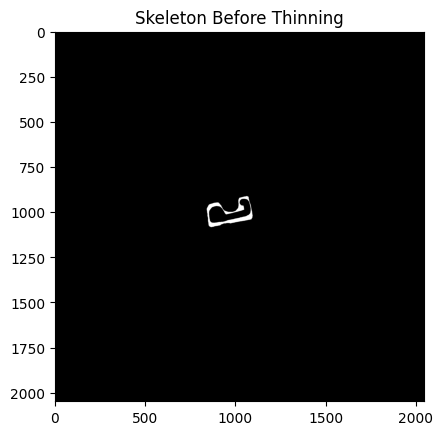

In [63]:
plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton Before Thinning')
plt.show()

In [64]:
# Check before thinning. If it’s low (e.g., <100 pixels), the input is too sparse.

cv2.countNonZero(skeleton)


10793

In [65]:
# Thinning to single-pixel width using morphological skeletonization
# Modified thinning with debug
def morphological_thinning(image):
    thinned = np.zeros_like(image)
    prev = np.zeros_like(image)
    curr = image.copy()
    kernel = np.ones((3, 3), np.uint8)
    iteration = 0
    while True:
        prev[:] = curr
        for _ in range(8):
            opened = cv2.morphologyEx(curr, cv2.MORPH_OPEN, kernel)
            hitmiss = cv2.morphologyEx(curr, cv2.MORPH_HITMISS, kernel)
            curr = cv2.subtract(curr, hitmiss)
        thinned = cv2.bitwise_or(thinned, curr)
        diff = cv2.countNonZero(cv2.subtract(prev, curr))
        print(f"Iteration {iteration}: Remaining pixels = {cv2.countNonZero(curr)}, Diff = {diff}")
        iteration += 1
        if diff == 0:
            break
    return thinned


Iteration 0: Remaining pixels = 1828, Diff = 8965
Iteration 1: Remaining pixels = 1828, Diff = 0
Skeleton pixels after thinning: 1828


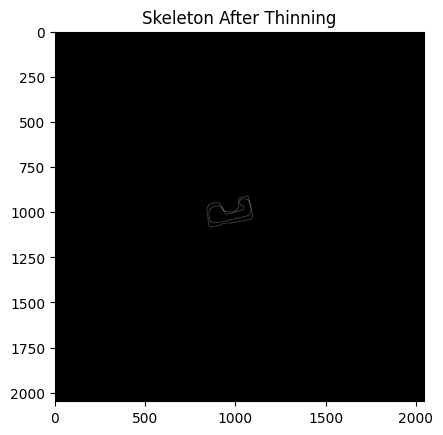

In [66]:
# Convert to uint8
skeleton = skeleton.astype(np.uint8)



kernel = np.ones((3, 3), np.uint8)
skeleton = morphological_thinning(skeleton)


# After thinning
print(f"Skeleton pixels after thinning: {cv2.countNonZero(skeleton)}")
plt.imshow(skeleton, cmap='gray')
plt.title('Skeleton After Thinning')
plt.show()


In [67]:
np.max(skeleton)

np.uint8(255)

In [68]:

# Extract skeleton coordinates
skeleton_coords = np.where(skeleton > 0)
skeleton_points = [(x, y) for y, x in zip(skeleton_coords[0], skeleton_coords[1])]

In [69]:



# Optionally sort points (simplified nearest-neighbor approach)
if skeleton_points:
    sorted_skeleton = [skeleton_points[0]]
    remaining = skeleton_points[1:]
    while remaining:
        last_point = sorted_skeleton[-1]
        distances = [np.sqrt((p[0] - last_point[0])**2 + (p[1] - last_point[1])**2) for p in remaining]
        closest_idx = np.argmin(distances)
        if distances[closest_idx] < 10:  # Distance threshold to avoid jumps
            sorted_skeleton.append(remaining.pop(closest_idx))
        else:
            break  # Stop if gap is too large
    skeleton_points = sorted_skeleton


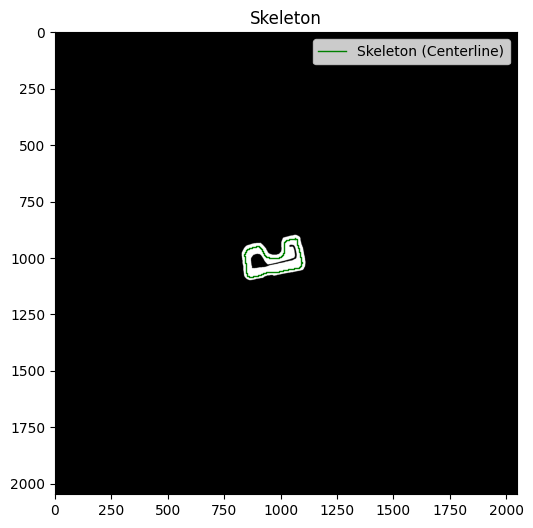

In [70]:

# Plot the skeleton
plt.figure(figsize=(8, 6))
plt.imshow(binary, cmap='gray')
skeleton_x = [p[0] for p in skeleton_points]
skeleton_y = [p[1] for p in skeleton_points]
plt.plot(skeleton_x, skeleton_y, 'g-', linewidth=1, label='Skeleton (Centerline)')
plt.title('Skeleton')
plt.legend()
plt.show()

# Save skeleton to CSV
if output_path:
    with open(output_path / 'skeleton.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(skeleton_points)

## Adjust the Threshold Dynamically
Instead of a fixed max_dist * 0.5, try a lower or adaptive threshold to include more of the central region:


Using OpenCV thinning.


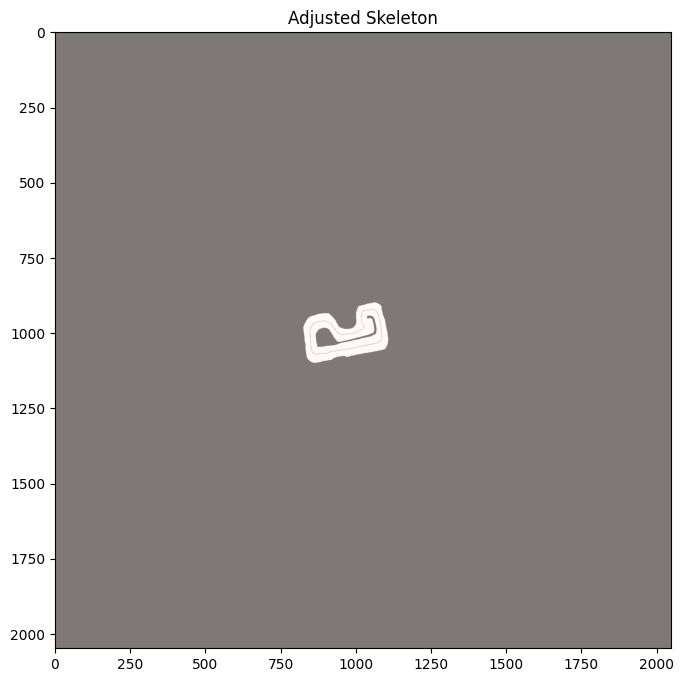

Skeleton pixels: 743


In [71]:
dist_transform = cv2.distanceTransform(binary, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary > 0])
thresh_value = max_dist * 0.3  # Try 0.3 or 0.2 to widen the skeleton initially
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY)
skeleton = skeleton.astype(np.uint8)

# Optional: Thin it
try:
    import cv2
    skeleton = cv2.ximgproc.thinning(skeleton)  # Preferred if available
    print("Using OpenCV thinning.")
except ImportError:
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)

# Check result
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Adjusted Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

## Smooth the Binary Image First

If the track’s boundaries are jagged or uneven, smooth them before the distance transform:


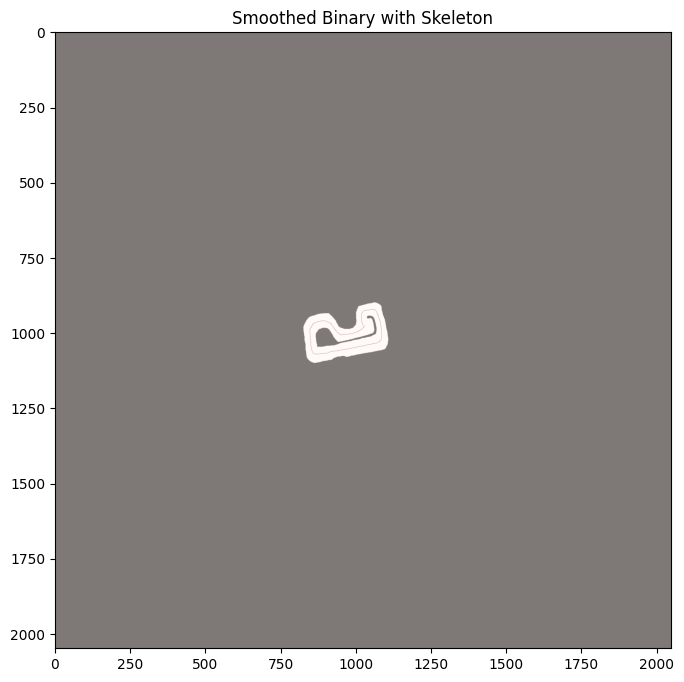

In [72]:
# Smooth binary to even out boundaries
binary_smoothed = cv2.GaussianBlur(binary, (5, 5), 0)
_, binary_smoothed = cv2.threshold(binary_smoothed, 127, 255, cv2.THRESH_BINARY)

dist_transform = cv2.distanceTransform(binary_smoothed, cv2.DIST_L2, 5)
max_dist = np.max(dist_transform[binary_smoothed > 0])
thresh_value = max_dist * 0.4  # Middle ground
_, skeleton = cv2.threshold(dist_transform, thresh_value, 255, cv2.THRESH_BINARY) # type: ignore
skeleton = skeleton.astype(np.uint8)

# Thin it
try:
    skeleton = cv2.ximgproc.thinning(skeleton)
except ImportError:
    kernel = np.ones((3, 3), np.uint8)
    skeleton = cv2.erode(skeleton, kernel, iterations=1)

y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'smoothed_binary_skeleton.png'), skeleton)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary_smoothed, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Smoothed Binary with Skeleton')
plt.show()



## Use a completely different approach with a Medial Axis Transform

The Medial Axis Transform (MAT) is a skeletonization algorithm that is based on the distance transform. The MAT is a thinning algorithm that reduces the binary image to its skeleton. The skeleton is a set of lines that are equidistant to the edges of the binary image. The MAT is a powerful tool for shape analysis and pattern recognition.

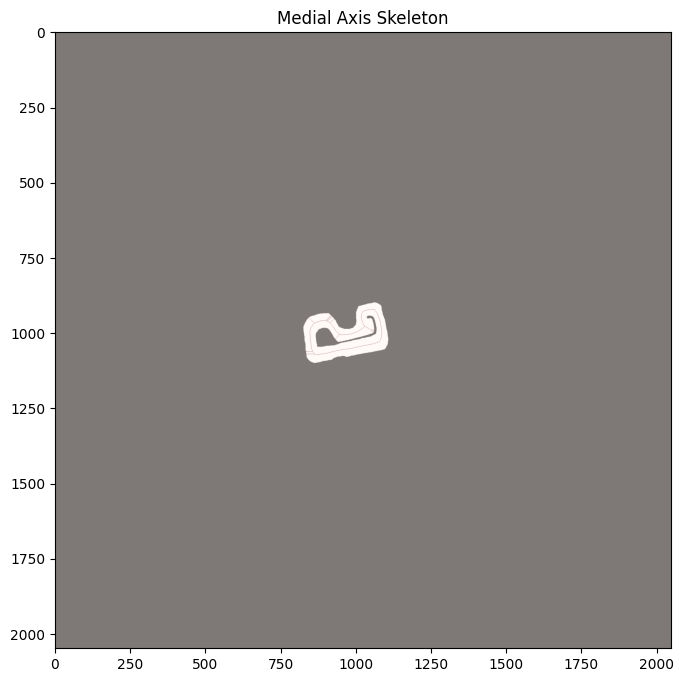

Skeleton pixels: 880


In [73]:
from skimage.morphology import skeletonize, medial_axis
import numpy as np

# Convert binary to boolean (True for 255, False for 0)
binary_bool = binary > 0

# Medial axis transform (returns skeleton and distance)
skeleton, distance = medial_axis(binary_bool, return_distance=True)

# Convert back to uint8
skeleton = (skeleton * 255).astype(np.uint8)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(skeleton, cmap='Reds', alpha=0.5)
plt.title('Medial Axis Skeleton')
plt.show()
print(f"Skeleton pixels: {cv2.countNonZero(skeleton)}")

y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'medial_axis_smoothed_skeleton.png'), skeleton)

## Final smoothing


## With Gausssian Blur

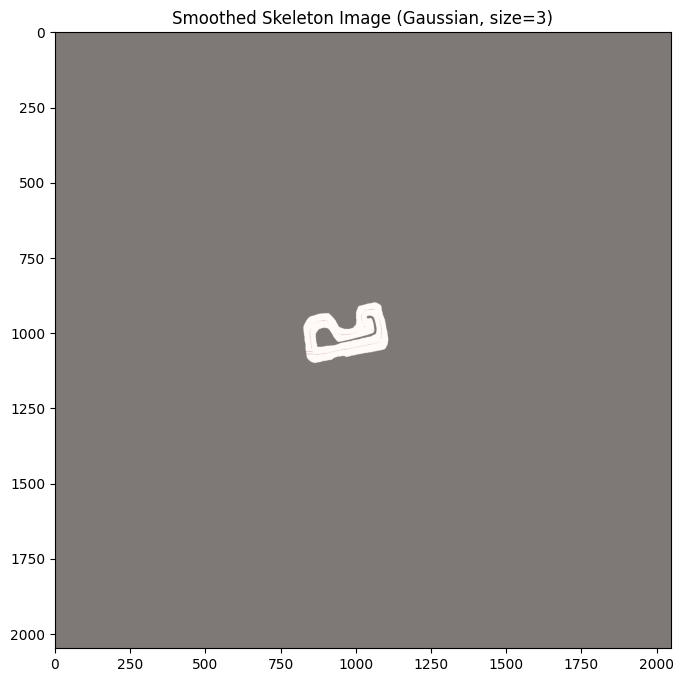

In [74]:
# Assuming 'skeleton' is your (2048, 2048) binary image
smooth_factor = 3  # Kernel size (odd number: 3, 5, 7)
smoothed_skeleton = cv2.GaussianBlur(skeleton, (smooth_factor, smooth_factor), 0)
_, smoothed_skeleton = cv2.threshold(smoothed_skeleton, 127, 255, cv2.THRESH_BINARY)

# Optional: Re-thin to ensure 1-pixel width
try:
    smoothed_skeleton = cv2.ximgproc.thinning(smoothed_skeleton)
except ImportError:
    kernel = np.ones((3, 3), np.uint8)
    smoothed_skeleton = cv2.erode(smoothed_skeleton, kernel, iterations=1)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(smoothed_skeleton, cmap='Reds', alpha=0.5)
plt.title(f'Smoothed Skeleton Image (Gaussian, size={smooth_factor})')
plt.show()

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'smoothed_skeleton.png'), smoothed_skeleton)

### Smooth the Skeleton Coordinates with a Moving Average

If you’ve extracted the skeleton points (e.g., skeleton_points as a list of (x, y) coordinates), smooth them with a moving average:

In [75]:
skeleton.shape

(2048, 2048)

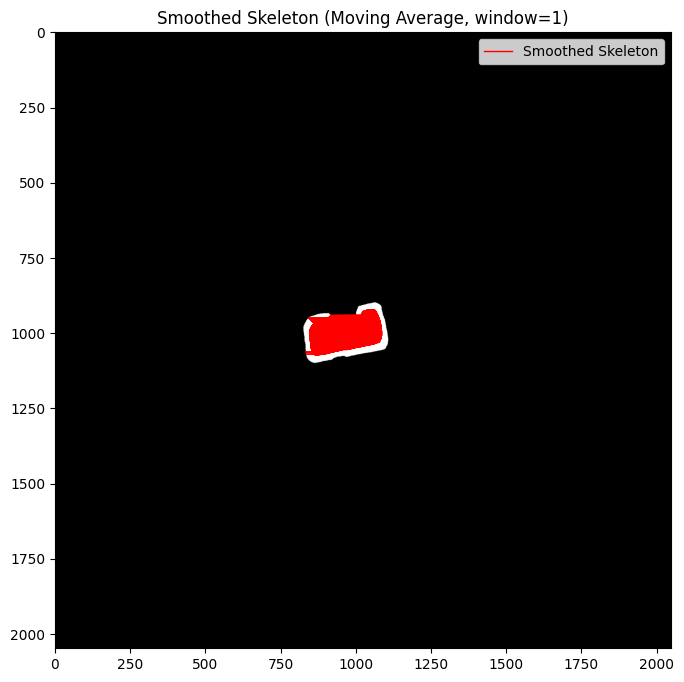

In [76]:
import numpy as np

# Assuming skeleton_points is a list of (x, y) coordinates
# Extract points from the (2048, 2048) skeleton image
y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Smoothing parameter: window size for moving average
window_size = 1  # Final parameter: number of points to average (odd, e.g., 3, 5, 7)

# Pad the array to handle edges (repeat first/last points)
pad_size = window_size // 2
padded_points = np.pad(skeleton_points, ((pad_size, pad_size), (0, 0)), mode='edge')

# Compute moving average
smoothed_points = np.zeros_like(skeleton_points, dtype=float)
for i in range(len(skeleton_points)):
    smoothed_points[i] = np.mean(padded_points[i:i + window_size], axis=0)

# Convert back to integer coordinates
smoothed_points = smoothed_points.astype(int)

# Create a new skeleton image from smoothed points
smoothed_skeleton = np.zeros_like(skeleton)
for x, y in smoothed_points:
    if 0 <= y < smoothed_skeleton.shape[0] and 0 <= x < smoothed_skeleton.shape[1]:
        smoothed_skeleton[y, x] = 255

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.plot(smoothed_points[:, 0], smoothed_points[:, 1], 'r-', linewidth=1, label='Smoothed Skeleton')
plt.title(f'Smoothed Skeleton (Moving Average, window={window_size})')
plt.legend()
plt.show()

# Save coordinates if needed
if output_path:
    with open(output_path / 'smoothed_skeleton.csv', 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['x', 'y'])
        writer.writerows(smoothed_points)

## Spline Smoothing with Image Rebuild

For a spline-based approach:

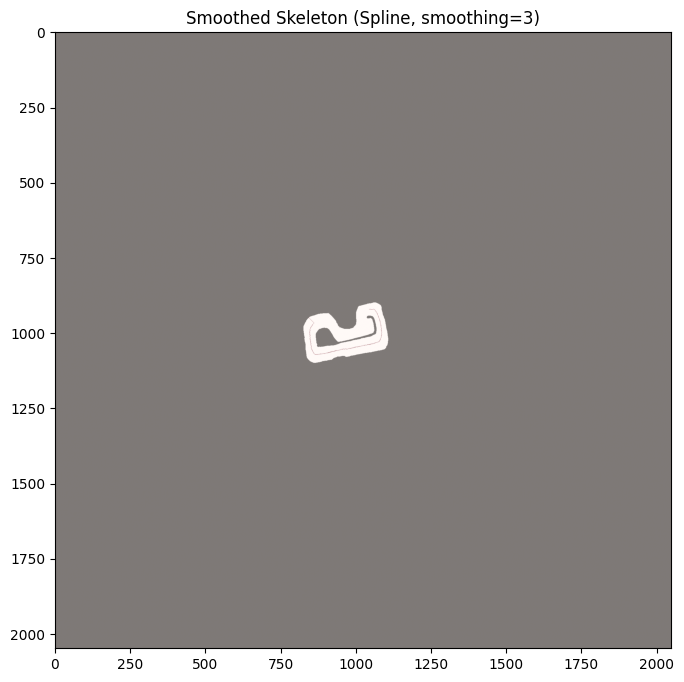

In [77]:
from scipy.interpolate import splprep, splev
import numpy as np

# Extract points from the (2048, 2048) skeleton image
y_coords, x_coords = np.where(skeleton > 0)  # Get row (y) and column (x) indices
skeleton_points = np.array(list(zip(x_coords, y_coords)))  # Combine into (x, y) pairs

# Sort points
sorted_points = [skeleton_points[0]]
remaining = list(skeleton_points[1:])
while remaining:
    last = sorted_points[-1]
    distances = np.sqrt(((remaining - last) ** 2).sum(axis=1))
    closest_idx = np.argmin(distances)
    if distances[closest_idx] < 10:
        sorted_points.append(remaining.pop(closest_idx))
    else:
        break
skeleton_points = np.array(sorted_points)

# Smoothing parameter
smoothing_factor = 3  # Try 5, 10, 20

# Fit spline
tck, u = splprep([skeleton_points[:, 0], skeleton_points[:, 1]], s=smoothing_factor, per=0)
smoothed_x, smoothed_y = splev(np.linspace(0, 1, len(skeleton_points) * 2), tck)
smoothed_points = np.vstack((smoothed_x, smoothed_y)).T.astype(int)

# Rebuild the image
smoothed_skeleton = np.zeros_like(skeleton)  # Shape (2048, 2048)
for x, y in smoothed_points:
    if 0 <= y < smoothed_skeleton.shape[0] and 0 <= x < smoothed_skeleton.shape[1]:
        smoothed_skeleton[y, x] = 255

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(smoothed_skeleton, cmap='Reds', alpha=0.5)
plt.title(f'Smoothed Skeleton (Spline, smoothing={smoothing_factor})')
plt.show()

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'smoothed_skeleton.png'), smoothed_skeleton)



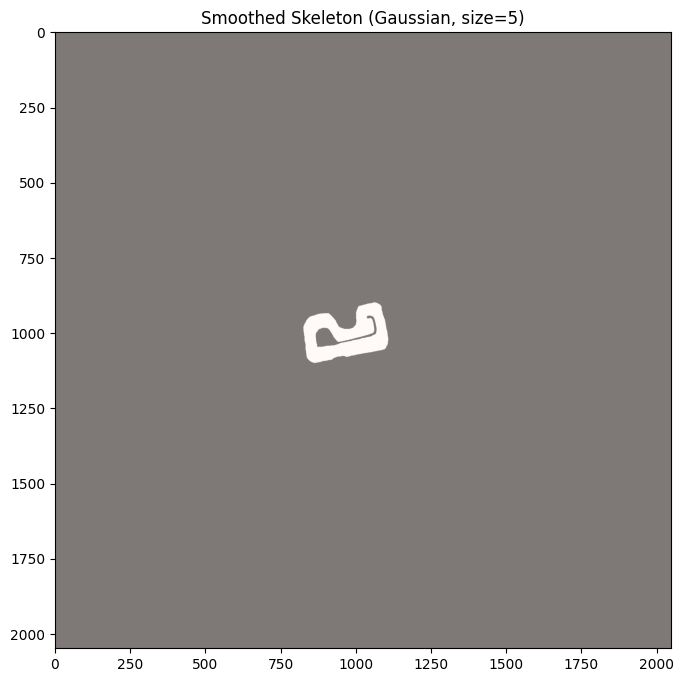

In [78]:
# Assuming 'skeleton' is your final skeleton image (uint8, 0s and 255s)
smooth_factor = 5  # Final parameter: Gaussian kernel size (odd number, e.g., 3, 5, 7)
smoothed_skeleton = cv2.GaussianBlur(skeleton, (smooth_factor, smooth_factor), 0)
_, smoothed_skeleton = cv2.threshold(smoothed_skeleton, 127, 255, cv2.THRESH_BINARY)

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(binary, cmap='gray')
plt.imshow(smoothed_skeleton, cmap='Reds', alpha=0.5)
plt.title(f'Smoothed Skeleton (Gaussian, size={smooth_factor})')
plt.show()

# Save if needed
if output_path:
    cv2.imwrite(str(output_path / 'smoothed_skeleton.png'), smoothed_skeleton)